# P3: Oldindan o'qitilgan embeddinglar bilan ishlash

**Mavzu:** word embeddings, kosinus o'xshashlik, analogiya, PCA vizualizatsiya  
**Kun:** 4-kun amaliyoti — Day 3 vektor-fazo ma'ruzasiga bog'langan practice  
**Ma'lumot:** offline mini word2vec fayl `uz_mini.vec`  
**GPU:** kerak emas; Kaggle CPU yetarli.

Bugun katta `cc_uz_100k.kv` o'rniga kichik, deterministic `uz_mini.vec` bilan ishlaymiz. Maqsad katta modelni train qilish emas; vektor fazo operatsiyalarini tushunish.

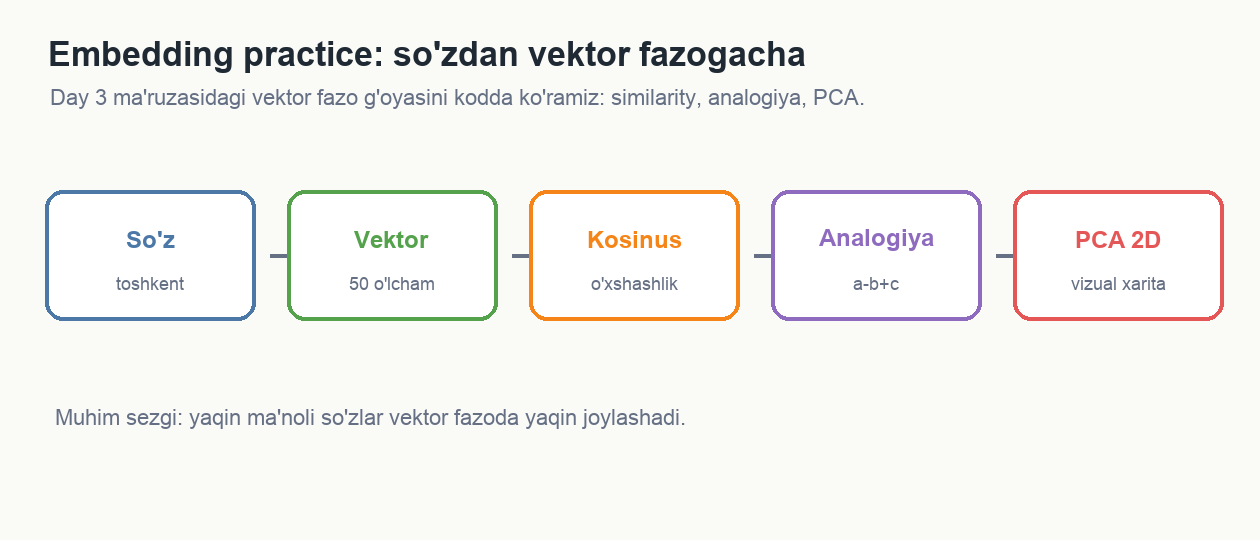

**Bugungi maqsadlar:**
1. Word2Vec `.vec` formatini yuklash.
2. So'z vektorini olish va OOV holatini ko'rish.
3. Kosinus similarity va `most_similar` yozish.
4. `toshkent - uzbekiston + rossiya ≈ moskva` analogiyasini tekshirish.
5. PCA bilan embeddinglarni 2D ko'rish.
6. `PretrainedEmbedder` klassining yengil capstone previewini ko'rish.


In [ ]:
# ============================================================
# 1. Muhit tekshiruvi va vector faylni topish
# ============================================================
import random, sys
from pathlib import Path
import numpy as np

random.seed(42)
np.random.seed(42)

SAVE_CAPSTONE_MODULE = False  # True -> m03_pretrained_embedder.py faylga yoziladi (ixtiyoriy)


def find_vector_file(filename: str = 'uz_mini.vec') -> Path | None:
    candidates = []
    kaggle_root = Path('/kaggle/input')
    if kaggle_root.exists():
        candidates.extend(kaggle_root.rglob(filename))
    candidates.extend([
        Path('d04_checkpoints') / filename,
        Path('practices/d04_checkpoints') / filename,
        Path('../practices/d04_checkpoints') / filename,
        Path(filename),
    ])
    return next((path for path in candidates if path.exists()), None)

VECTOR_PATH = find_vector_file('uz_mini.vec')
assert VECTOR_PATH is not None, (
    "uz_mini.vec topilmadi. Kaggle datasetga practices/d04_checkpoints/uz_mini.vec yoki "
    "faylning o'zini upload qiling."
)

MODULES_DIR = Path('capstone/modules')

import sklearn
print(f"Python      : {sys.version.split()[0]}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"numpy       : {np.__version__}")
try:
    import matplotlib
    print(f"matplotlib  : {matplotlib.__version__}")
except ImportError:
    print("matplotlib  : yo'q — PCA jadval sifatida ko'rsatiladi")
try:
    import gensim
    print(f"gensim      : {gensim.__version__} (katta .kv yuklash uchun optional)")
except ImportError:
    print("gensim      : yo'q — bu practice .vec ni numpy bilan o'qiydi")
print(f"Vector file : {VECTOR_PATH}")
print("Muhit tayyor.")


## 2. Darsda ko'rsatiladigan barcha natijalarni ko'rib chiqamiz  

Quyida **tugallangan embedding demosi** ishga tushadi: vektorlarni yuklaymiz va
`toshkent` ga eng o'xshash so'zlarni topamiz. Avval natijani ko'rib olamiz.

In [ ]:
# Pirovard natija (5-bo'limda quriladigan m03 ning soddalashtirilgan versiyasi)
from pathlib import Path
import numpy as np

def load_w2v_text(path):
    # Word2vec matn formatini gensimsiz o'qiydi -> (words, matritsa, w2i)
    words, rows = [], []
    with open(path, encoding="utf-8") as f:
        f.readline()               # "n dim" sarlavhasini o'tkazib yuboramiz
        for line in f:
            parts = line.rstrip("\n").split(" ")
            if len(parts) < 2:
                continue
            words.append(parts[0])
            rows.append(np.asarray(parts[1:], dtype=np.float32))
    M = np.vstack(rows)
    w2i = {w: i for i, w in enumerate(words)}
    return words, M, w2i

words, M, w2i = load_w2v_text(VECTOR_PATH)
Mn = M / np.linalg.norm(M, axis=1, keepdims=True)

def quick_similar(word, n=5):
    i = w2i[word]
    sims = Mn @ Mn[i]
    order = [j for j in np.argsort(-sims) if j != i][:n]
    return [(words[j], float(sims[j])) for j in order]

print(f"Yuklandi: {len(words)} so'z, {M.shape[1]} o'lchamli vektorlar")
print("\n'toshkent' ga eng o'xshash so'zlar:")
for w, s in quick_similar("toshkent", 5):
    print(f"  {w:14s} {s:.3f}")
print("\n✓ Pipeline ishladi! Quyida har qadamni o'rganamiz.")

## 3. Tayyor kod bloki — PRIMM

### 3A. Vektorlarni yuklash

> **Bashorat qiling:**
> Kaggle da haqiqiy `cc_uz_100k.kv` (~240 MB) gensim bilan yuklanadi. Offline esa
> kichik `.vec` namuna. Sizningcha, 100 000 so'zli model nechta vektor saqlaydi?

In [ ]:
# To'liq berilgan kod (PRIMM — periphery)
# Kaggle (onlayn) da haqiqiy model gensim bilan yuklanadi:
#   from gensim.models import KeyedVectors
#   wv = KeyedVectors.load("cc_uz_100k.kv")        # ~240 MB, 100k so'z
#   words = list(wv.index_to_key); M = wv.vectors
#
# Offline (bu mashg'ulot) da bundled kichik namuna ishlatiladi:
words, M, w2i = load_w2v_text(VECTOR_PATH)
Mn = M / np.linalg.norm(M, axis=1, keepdims=True)

print(f"So'zlar soni  : {len(words)}")
print(f"Vektor o'lchami: {M.shape[1]}")
print(f"Lug'at namunasi: {words[:8]}")
print(f"'toshkent' vektori (birinchi 5 son): {M[w2i['toshkent']][:5].round(2)}")

> **Tekshiring:**
> 1. `M` matritsasining shakli (`M.shape`) nimaga teng? Qatorlar = so'zlar?
> 2. `Mn` (normallashtirilgan) qatorlarining normasi nechiga teng? (`np.linalg.norm(Mn[0])`)
> 3. Nega kosinus uchun vektorlarni normallashtramiz?

> **O'zgartiring:** `words` ro'yxatidan boshqa so'z tanlab, uning vektorini chop eting.


### 3B. PCA bilan 2D vizualizatsiya

> **Bashorat qiling:**
> Yuqori o'lchamli vektorlarni PCA bilan 2D ga tushirsak, qaysi so'zlar yaqin
> klasterlarga tushadi? (Shaharlar? Taomlar?)

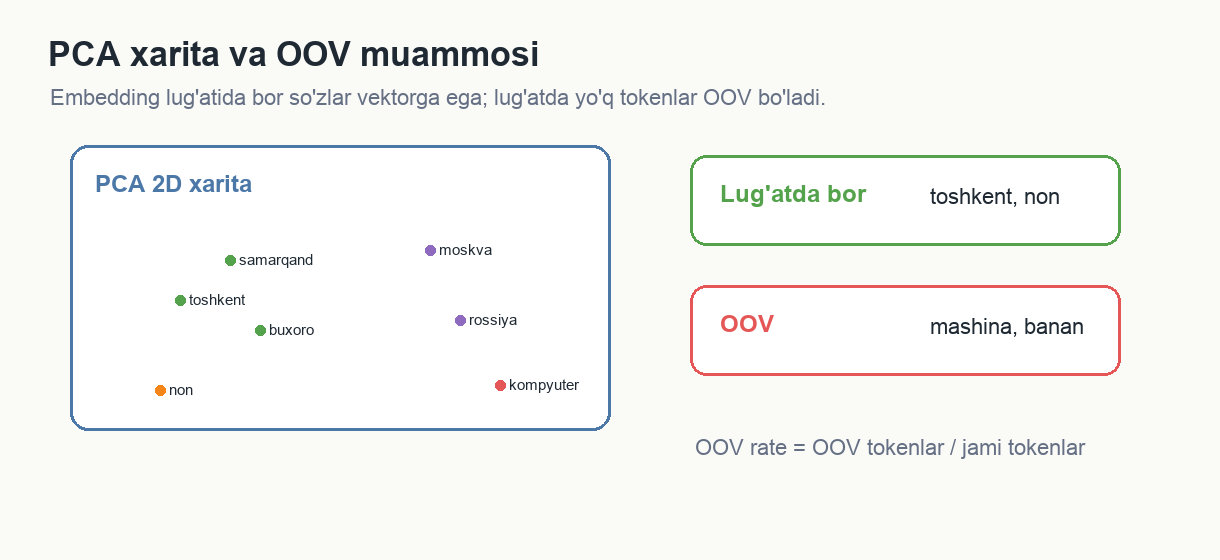


In [ ]:
# To'liq berilgan kod (PRIMM — periphery)
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
xy = pca.fit_transform(M)
print(f"explained_variance_ratio_: {pca.explained_variance_ratio_.round(3)}")

try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(7, 5))
    plt.scatter(xy[:, 0], xy[:, 1], s=12, color="tab:blue")
    for i, w in enumerate(words):
        plt.annotate(w, (xy[i, 0], xy[i, 1]), fontsize=7)
    plt.title("Embeddinglar — PCA 2D")
    plt.tight_layout(); plt.show()
except Exception as ex:
    print(f"(grafik o'tkazib yuborildi: {type(ex).__name__})")
    ci = w2i["toshkent"]; cj = w2i["samarqand"]; ck = w2i["non"]
    print(f"PCA masofa toshkent-samarqand: {np.linalg.norm(xy[ci]-xy[cj]):.2f}")
    print(f"PCA masofa toshkent-non       : {np.linalg.norm(xy[ci]-xy[ck]):.2f}")

> **Tekshiring:**
> 1. Ikki komponent ma'lumotning qancha qismini saqladi (`explained_variance_ratio_` yig'indisi)?
> 2. Shaharlar (toshkent, samarqand) bir-biriga taomlardan (non) yaqinroqmi?
> 3. 2D rasm — taxminiy. To'liq fazoda yaqinlik kafolatlanadimi? (L3 [J4]-slayd)


In [ ]:
# Sanity check: yuklangan vektorlar keyingi bo'limlar uchun tayyor
assert len(words) > 0 and M.shape[0] == len(words)
assert M.shape[1] == 50, "Mini embedding faylida 50 o'lchamli vektorlar kutilgan."
assert "toshkent" in w2i and "moskva" in w2i
print(f"Tayyor: {len(words)} so'z, vektor o'lchami {M.shape[1]}.")


## 4. Asosiy mavzu — so'nuvchi tayanch

Uch bosqich: **Namuna** (men ko'rsataman) → **Birgalikda** (`# === SIZNING KODINGIZ ===`)
→ **Mustaqil** (siz qilasiz).

### 4A. Namuna: kosinus o'xshashlik — L3 [I2]-slayd

L3 ma'ruzasidagi qo'lda misol: $\mathbf{a}=(1,1,1,0)$, $\mathbf{b}=(1,1,0,1)$ uchun
$\cos = 2/3 \approx 0.667$. Buni `cosine_similarity` bilan tekshiramiz.

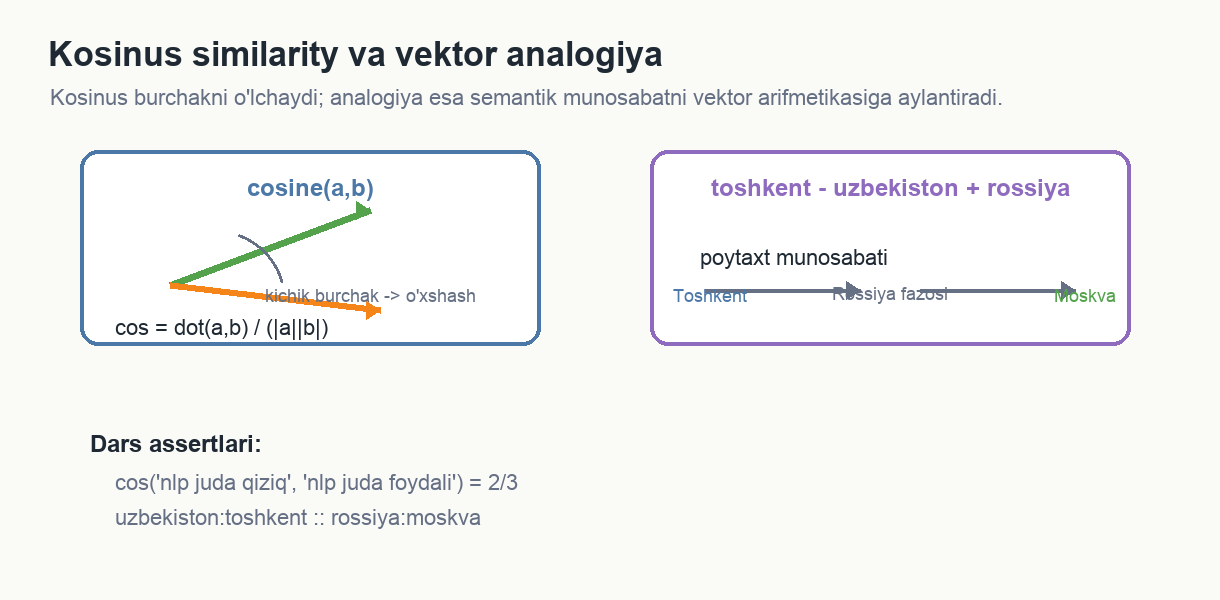


In [ ]:
# Namuna (men ko'rsataman): kosinus o'xshashlik
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Ma'ruza L3 [I2]-slayd: "nlp juda qiziq" vs "nlp juda foydali"
# Lug'at: (nlp, juda, qiziq, foydali)
a = np.array([[1, 1, 1, 0]])
b = np.array([[1, 1, 0, 1]])

cos_val = float(cosine_similarity(a, b)[0, 0])
print(f"cosine(a, b) = {cos_val:.4f}   (kutilgan: 2/3 = {2/3:.4f})")

assert abs(cos_val - 0.667) < 1e-3, (
    f"cosine={cos_val:.4f}, kutilgan 0.667. Vektorlarni tekshiring."
)
# Ma'ruza L3 [I2]-slayd bilan solishtiring
print("✓ Ma'ruza L3 [I2]-slayd tasdiqlandi: cos = 2/3 ≈ 0.667")

### 4B. Birgalikda: most_similar — eng o'xshash so'zlar

Normallashtirilgan matritsa `Mn` da kosinus = skalyar ko'paytma. So'rov so'zining
qatorini butun matritsaga ko'paytirib, eng yuqorilarini topamiz.

In [ ]:
# Birgalikda: most_similar
def most_similar_local(word, n=5):
    i = w2i[word]
    # === SIZNING KODINGIZ (1 qator) ===
    # Mn[i] vektorini butun Mn matritsasiga skalyar ko'paytiring -> sims
    sims = None
    order = [j for j in np.argsort(-sims) if j != i][:n]
    return [(words[j], float(sims[j])) for j in order]

natija = most_similar_local("toshkent", 5)

In [ ]:
cities = {"samarqand", "buxoro", "andijon", "namangan", "xiva", "nukus"}
top_words = [w for w, _ in natija]
assert len(natija) == 5, "most_similar 5 ta natija qaytarishi kerak."
assert top_words[0] in cities, (
    f"'toshkent' ga eng yaqin so'z o'zbek shahri bo'lishi kutilgan, '{top_words[0]}' chiqdi."
)
assert "moskva" not in top_words[:3], "moskva (boshqa davlat) top-3 da bo'lmasligi kerak."
print(f"✓ most_similar to'g'ri: toshkent ~ {top_words[:3]} (o'zbek shaharlari)")

### 4C. Birgalikda: so'z analogiyasi — vektor arifmetikasi

L3 [I3]-slayd: `uzbekiston : toshkent :: rossiya : ?`. Maqsad vektor
$\mathbf{t} = \text{toshkent} - \text{uzbekiston} + \text{rossiya}$, eng yaqini = javob.

In [ ]:
# Birgalikda: so'z analogiyasi
def nearest_to_vec(vec, exclude=(), n=1):
    vn = vec / (np.linalg.norm(vec) + 1e-9)
    sims = Mn @ vn
    out = []
    for j in np.argsort(-sims):
        if words[j] in exclude:
            continue
        out.append((words[j], float(sims[j])))
        if len(out) >= n:
            break
    return out

# === SIZNING KODINGIZ (1 qator) ===
# Maqsad vektor: toshkent - uzbekiston + rossiya  (M xom vektorlardan)
t = None

javob = nearest_to_vec(t, exclude={"toshkent", "uzbekiston", "rossiya"}, n=1)

In [ ]:
assert t is not None, "Maqsad vektor t None. toshkent - uzbekiston + rossiya ni hisoblang."
assert javob[0][0] == "moskva", (
    f"Analogiya 'moskva' bo'lishi kutilgan, '{javob[0][0]}' chiqdi. "
    "Vektor arifmetikasini tekshiring: b - a + c."
)
print("✓ Analogiya to'g'ri: uzbekiston:toshkent :: rossiya:moskva (poytaxt munosabati)")

### 4D. Birgalikda: OOV ulushi (oov_rate)

OOV (out-of-vocabulary) — lug'atda yo'q so'zlar. Ularning ulushi o'zbek tilida
yuqori bo'ladi (L3 [M]-slayd: agglutinatsiya + inglizcha-asosli vektorlar).

In [ ]:
# Birgalikda: oov_rate
def oov_rate_local(texts):
    # texts: list[list[str]] -> lug'atda yo'q tokenlar ulushi [0,1]
    total = oov = 0
    for toks in texts:
        for tok in toks:
            total += 1
            # === SIZNING KODINGIZ (1-2 qator) ===
            # tok lug'atda (w2i) yo'q bo'lsa, oov ni oshiring
            pass
    return oov / total if total else 0.0

namuna = [["toshkent", "non", "kompyuter"], ["mashina", "internet", "banan"]]
rate = oov_rate_local(namuna)

In [ ]:
# Lug'atda: toshkent, non, kompyuter, internet (4). OOV: mashina, banan (2). Jami 6.
assert abs(rate - 2/6) < 0.01, (
    f"OOV ulushi {rate:.3f}, kutilgan {2/6:.3f}. Sanashni tekshiring."
)
print(f"✓ oov_rate to'g'ri: 6 tokendan 2 tasi (mashina, banan) OOV -> {rate:.3f}")

### 4E. Mustaqil: o'z so'zlaringiz bilan sinab ko'ring

Scaffold yo'q — yuqorida o'rgangan `most_similar_local` va `nearest_to_vec` dan
foydalaning.

In [ ]:
# Mustaqil (siz qilasiz): o'z so'zlaringiz bilan sinab ko'ring
# 1. Biror so'z tanlang (masalan "non", "kompyuter") va eng o'xshashlarini toping.
# 2. Yangi analogiya yarating (masalan oziq-ovqat yoki texnologiya guruhida).
my_word = "kompyuter"
# === SIZNING KODINGIZ ===
my_similar = None

In [ ]:
assert my_similar is not None, "my_similar None. most_similar_local() ni qo'llang."
assert len(my_similar) == 3, "3 ta o'xshash so'z kutilgan."
assert all(isinstance(w, str) for w, _ in my_similar), "Har element (so'z, son) bo'lishi kerak."
print(f"✓ Mustaqil: '{my_word}' ~ {[w for w, _ in my_similar]}")

## 5. Yengil loyiha preview — `PretrainedEmbedder`

4-bo'limdagi funksiyalarni bitta qayta ishlatiladigan klassga o'raymiz. Bugun capstone papka arxitekturasini chuqur ochmaymiz; klass notebook ichida ishlaydi. Agar keyin kerak bo'lsa, `SAVE_CAPSTONE_MODULE = True` qilib Python fayliga ham saqlash mumkin.


In [ ]:
# m03 PretrainedEmbedder — inline ta'rif (Option C)
import numpy as np

class PretrainedEmbedder:
    # Gensim .kv yoki word2vec .vec embeddinglarni boshqaradi.
    # Interfeys: load(path) | embed(word) | most_similar(word, n) | oov_rate(texts)
    # Consumed by: m04 (LSH), m08 (GRU/LSTM pretrained init).

    def __init__(self):
        self._words = []
        self._w2i = {}
        self._raw = None    # (n, dim) xom vektorlar, float32
        self._norm = None   # (n, dim) L2-normallashtirilgan (kosinus uchun)
        self._dim = 0

    def load(self, path):
        # Gensim KeyedVectors (.kv) yoki word2vec matn (.vec) yuklaydi.
        path = str(path)
        if path.endswith(".kv"):
            from gensim.models import KeyedVectors
            kv = KeyedVectors.load(path)
            words = list(kv.index_to_key)
            mat = np.asarray(kv.vectors, dtype=np.float32)
        else:
            words, mat = self._load_text(path)
        self._words = words
        self._w2i = {w: i for i, w in enumerate(words)}
        self._raw = mat.astype(np.float32)
        self._dim = mat.shape[1]
        norms = np.linalg.norm(mat, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        self._norm = (mat / norms).astype(np.float32)

    @staticmethod
    def _load_text(path):
        words, rows = [], []
        with open(path, encoding="utf-8") as f:
            first = f.readline().split()
            # sarlavha "n dim" bo'lsa o'tkazib yuboramiz, aks holda ma'lumot
            if not (len(first) == 2 and first[0].isdigit() and first[1].isdigit()):
                words.append(first[0])
                rows.append(np.asarray(first[1:], dtype=np.float32))
            for line in f:
                parts = line.rstrip("\n").split(" ")
                if len(parts) < 2:
                    continue
                words.append(parts[0])
                rows.append(np.asarray(parts[1:], dtype=np.float32))
        return words, np.vstack(rows)

    def embed(self, word):
        # OOV uchun sifr-vektori qaytariladi (shape (dim,) float32)
        i = self._w2i.get(word)
        if i is None:
            return np.zeros(self._dim, dtype=np.float32)
        return self._raw[i].copy()

    def most_similar(self, word, n=5):
        # Kosinus bo'yicha eng o'xshash n ta so'z: [(so'z, o'xshashlik), ...]
        i = self._w2i.get(word)
        if i is None:
            return []
        sims = self._norm @ self._norm[i]
        order = np.argsort(-sims)
        out = []
        for j in order:
            if int(j) == i:
                continue
            out.append((self._words[int(j)], float(sims[int(j)])))
            if len(out) >= n:
                break
        return out

    def oov_rate(self, texts):
        # Tokenlar orasida lug'atda yo'q so'zlar ulushi [0,1]
        total = oov = 0
        for toks in texts:
            for t in toks:
                total += 1
                if t not in self._w2i:
                    oov += 1
        return oov / total if total else 0.0

print("✓ PretrainedEmbedder sinfi aniqlandi.")

In [ ]:
# Shartnoma tekshiruvi
emb = PretrainedEmbedder()
emb.load(VECTOR_PATH)

import numpy as np

# embed -> np.ndarray, OOV -> sifr-vektori
v = emb.embed("toshkent")
assert isinstance(v, np.ndarray) and v.shape == (50,), "embed() (50,) ndarray qaytarishi kerak."
assert np.allclose(emb.embed("yoqyoqyoq"), 0.0), "OOV uchun sifr-vektori kutilgan."

# most_similar -> list[tuple[str, float]]
ms = emb.most_similar("toshkent", 5)
assert len(ms) == 5 and isinstance(ms[0][0], str) and isinstance(ms[0][1], float)
assert ms[0][0] in {"samarqand", "buxoro", "andijon", "namangan", "xiva", "nukus"}

# oov_rate -> float [0,1]
r = emb.oov_rate([["toshkent", "mashina"]])
assert 0.0 <= r <= 1.0 and abs(r - 0.5) < 1e-9, "oov_rate noto'g'ri."

# Kapstone uzviyligi: m01 bilan tokenize qilib oov_rate
try:
    from m01_text_preprocessor import TextPreprocessor
    tp = TextPreprocessor()
    toks = tp.preprocess("Toshkent va Samarqand go'zal shaharlar")
    r2 = emb.oov_rate([toks])
    assert 0.0 <= r2 <= 1.0
    print(f"  m01 tokenlari OOV ulushi      = {r2:.3f}")
except ImportError:
    print("  (m01 import yo'q — alohida ishlatiladi)")

print("✓ PretrainedEmbedder barcha shartnoma tekshiruvlaridan o'tdi!")
print(f"  most_similar('toshkent')[:3] = {[w for w,_ in ms[:3]]}")

In [ ]:
# Ixtiyoriy: m03 ni faylga saqlash (SAVE_CAPSTONE_MODULE = True bo'lsa)
if SAVE_CAPSTONE_MODULE:
    import inspect
    header = chr(10).join([
        '"""PretrainedEmbedder — P3 notebookidan."""',
        'import numpy as np',
        '',
    ])
    path = Path('m03_pretrained_embedder.py')
    path.write_text(header + inspect.getsource(PretrainedEmbedder), encoding='utf-8')
    print(f'✓ m03 saqlandi: {path}')
else:
    print('SAVE_CAPSTONE_MODULE = False — fayl yozilmadi (kurs rejimi).')
    print("PretrainedEmbedder sinfi bu notebookda aniqlangan va tayyor.")


### 5C. Faylga saqlash haqida

Kaggle darsida faylga saqlash shart emas. `SAVE_CAPSTONE_MODULE = False` bo'lsa, keyingi kataklar faqat notebook ichidagi klassni ishlatadi.


In [ ]:
print("Yakun: Kaggle uchun notebook va uz_mini.vec fayli yetarli.")


## 6. Tadqiqot savoli + yakun

**Savol:** O'zbek matnlarida OOV ulushi nega yuqori? Apostrof variantlari
(`o'` / `oʻ` / `o`) bir xil so'zni turli token qiladi — bu embeddingga qanday ta'sir qiladi?

In [ ]:
# Mini tadqiqot: apostrof varianti OOV ga qanday ta'sir qiladi?
variantlar = ["to'g'ri", "tog'ri", "togri"]   # ASCII ', U+2019 yo'q, apostrofsiz
for w in variantlar:
    bor = w in w2i
    print(f"  {w:10s} lug'atda: {'BOR' if bor else 'YO'+chr(39)+'Q (OOV)'}")

# Agglutinatsiya: bir o'zak, ko'p shakl
shakllar = [["toshkent", "toshkentda", "toshkentdan", "toshkentga"]]
print(f"\nAgglutinativ shakllar OOV ulushi: {oov_rate_local(shakllar):.3f}")
print("Mulohaza: faqat 'toshkent' lug'atda; qo'shimchali shakllar OOV.")
print("Yechim: m01 bilan normallashtirish/stemming -> OOV kamayadi (P1 dan eslang).")


## Yakun

**Bugun nimalar qildik:**
- ✓ Oldindan o'qitilgan vektorlarni yukladik (Kaggle: gensim `.kv`; offline: `.vec`)
- ✓ Kosinus o'xshashlikni tasdiqladik — L3 [I2]-slayd: cos = 2/3 ≈ 0.667
- ✓ `most_similar` bilan eng o'xshash so'zlarni topdik (toshkent ~ o'zbek shaharlari)
- ✓ Vektor arifmetikasi bilan analogiyani yechdik (uzbekiston:toshkent :: rossiya:moskva)
- ✓ OOV ulushini o'lchadik va PCA bilan vizualizatsiya qildik
- ✓ m03 `PretrainedEmbedder` ni kapstone moduliga yozdik

**Keyingi amaliyot (P4 — imlo tuzatish va LSH qidiruv):**
m01 → edit_distance (DP) → noisy channel → MinHash LSH → m04 SpellLSHRetriever
Birinchi assert: `edit_distance("qo'l","ko'l")==1` (L4 [I3]-slayd)


**Chiqish chiptasi:** Bugun eng tushunarsiz qolgan narsa nima?
*(Quyidagi katakka yozing — keyingi darsda muhokama qilamiz.)*